# Nori vs XGBoost on Clinical & Payer Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sechan9999/synthefy-nori/blob/main/examples/notebooks/nori-vs-xgboost-clinical.ipynb)

Can a training-free tabular foundation model replace a tuned gradient-boosted model for healthcare regression? This notebook compares **Nori** (in-context learning, no tuning) with **XGBoost** (randomized hyperparameter search) on three public datasets:

| Dataset | Rows | Target | Validation unit |
|---|---:|---|---|
| [Diabetes progression](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) (Efron et al., 2004) | 442 patients | Disease progression score at 1 year | Patient (repeated K-fold) |
| [Parkinson's telemonitoring](https://www.openml.org/d/4531) (Tsanas et al., 2010) | 5,875 recordings / 42 patients | Total UPDRS from voice measures | **Patient (GroupKFold)** |
| [CMS Medicare inpatient charges](https://www.openml.org/d/42130) (FY2011) | 4,000 sampled provider-DRG rows | Average total payment per discharge | Provider-DRG row (K-fold) |

Both models are scored on:

- **Accuracy**: R², RMSE, MAE on held-out folds.
- **Uncertainty**: empirical coverage and width of 90% prediction intervals. Nori reads them from its predictive distribution; XGBoost gets a separate quantile model (`reg:quantileerror`) using its tuned parameters.
- **Cost**: wall-clock fit + predict time, including XGBoost's search.
- **Small-data behavior**: a learning curve from 50 to 1,000 training rows.
- **Leakage**: what happens to both models' Parkinson's scores when recordings from the same patient land in both train and test.

## Setup

The saved outputs use **`nori-30m` on a 6 GB laptop GPU (RTX 4050)**, with XGBoost on the CPU; the whole notebook ran in about 45 minutes. XGBoost's scores are identical to an earlier CPU-only run with `nori-6m`, which is what makes the model-size comparison in the findings fair.

- **Checkpoint**: `NORI_MODEL` selects it (default `nori-6m`, which runs on a CPU in about two hours).
- **GPU memory**: `NORI_GPU_MEM_FRACTION` caps PyTorch's share (default 0.85). On Windows, a full GPU otherwise spills into shared system memory and one fold went from 36 seconds to over 10 minutes.
- **Smoke run**: `QUICK=1` uses fewer folds and search iterations.

In [1]:
# Install only when the runtime does not already have Nori.
try:
    import synthefy_nori  # noqa: F401
except ImportError:
    %pip install -q "synthefy-nori" xgboost matplotlib

In [2]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.datasets import fetch_openml, load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV, RepeatedKFold
import torch
from synthefy_nori import NoriRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# On Windows, a full GPU silently spills into shared system memory and slows to a crawl.
# Capping PyTorch's share turns that into a real OOM, which Nori's memory ladder handles.
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(float(os.environ.get("NORI_GPU_MEM_FRACTION", "0.85")))

QUICK = os.environ.get("QUICK") == "1"
NORI_MODEL = os.environ.get("NORI_MODEL", "nori-6m")
N_SPLITS = 2 if QUICK else 5
XGB_SEARCH_ITERS = 3 if QUICK else 30
INTERVAL = (0.05, 0.95)  # 90% prediction interval
SEED = 0

DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Nori checkpoint: {NORI_MODEL} on {DEVICE} | folds: {N_SPLITS} | XGBoost search configs: {XGB_SEARCH_ITERS}")

Nori checkpoint: nori-30m on NVIDIA GeForce RTX 4050 Laptop GPU | folds: 5 | XGBoost search configs: 30


## Load the datasets

- **Diabetes** uses the unscaled clinical units (age, BMI, blood pressure, six serum measures).
- **Parkinson's** drops `motor_UPDRS`: it is a sub-score of the target and would leak it. `subject.` is kept only as the grouping key.
- **Medicare** drops `average_medicare_payments`, which is a component of the target, and keeps DRG, state, discharge volume, and billed covered charges. A 4,000-row random sample keeps CPU runtime reasonable.

In [3]:
diabetes = load_diabetes(as_frame=True, scaled=False)
X_diab, y_diab = diabetes.data, diabetes.target.to_numpy(float)

pk = fetch_openml(data_id=4531, as_frame=True, parser="auto").frame
groups_pk = pk["subject."].to_numpy()
X_pk = pk.drop(columns=["subject.", "motor_UPDRS", "total_UPDRS"]).astype(float)
y_pk = pk["total_UPDRS"].to_numpy(float)

mc = fetch_openml(data_id=42130, as_frame=True, parser="auto").frame
mc = mc.sample(n=1000 if QUICK else 4000, random_state=SEED).reset_index(drop=True)
MEDICARE_CATS = ["drg_definition", "provider_state"]
X_mc = mc[MEDICARE_CATS + ["total_discharges", "average_covered_charges"]].copy()
for col in MEDICARE_CATS:
    X_mc[col] = X_mc[col].astype(str).astype("category")
y_mc = mc["average_total_payments"].to_numpy(float)

DATASETS = {
    "Diabetes": dict(X=X_diab, y=y_diab, groups=None, cats=None,
                     cv=RepeatedKFold(n_splits=N_SPLITS, n_repeats=1 if QUICK else 2, random_state=SEED)),
    "Parkinson's": dict(X=X_pk, y=y_pk, groups=groups_pk, cats=None, cv=GroupKFold(n_splits=N_SPLITS)),
    "Medicare": dict(X=X_mc, y=y_mc, groups=None, cats=MEDICARE_CATS,
                     cv=KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)),
}
pd.DataFrame({name: {"rows": len(d["y"]), "features": d["X"].shape[1],
                     "patients / groups": len(np.unique(d["groups"])) if d["groups"] is not None else "-",
                     "target mean": round(d["y"].mean(), 1), "target std": round(d["y"].std(), 1)}
              for name, d in DATASETS.items()}).T

,rows,features,patients / groups,target mean,target std
Diabetes,442,10,-,152.1,77.0
Parkinson's,5875.0,19.0,42.0,29.0,10.7
Medicare,4000,4,-,9799.1,7737.1


## The two contenders

**Nori** gets the raw table (no scaling, categoricals declared, no hyperparameters). One `predict(output_type="full")` call returns the mean and the full 999-quantile distribution, so the 90% interval costs nothing extra.

**XGBoost** is tuned by randomized search with inner cross-validation on the training fold only. Inner folds are grouped by patient when the outer split is, so tuning never sees a test patient. The interval model reuses the winning parameters with a two-quantile pinball objective.

In [4]:
XGB_SPACE = {
    "n_estimators": randint(100, 1000),
    "max_depth": randint(2, 8),
    "learning_rate": loguniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": loguniform(1, 20),
    "reg_lambda": loguniform(0.1, 10),
}


DROPPED_CONTEXT_ROWS = []  # rows Nori discarded to fit memory; nonzero would be a real accuracy loss


def run_nori(X_tr, y_tr, X_te, cats):
    t0 = time.perf_counter()
    model = NoriRegressor(model=NORI_MODEL, categorical_columns=cats)
    model.fit(X_tr, y_tr)
    dist = model.predict(X_te, output_type="full")
    taus = np.asarray(dist["taus"])
    q = np.asarray(dist["quantiles"])
    lo = q[:, np.abs(taus - INTERVAL[0]).argmin()]
    hi = q[:, np.abs(taus - INTERVAL[1]).argmin()]
    DROPPED_CONTEXT_ROWS.append((model.memory_report_ or {}).get("dropped_context_rows") or 0)
    return np.asarray(dist["mean"]), lo, hi, time.perf_counter() - t0


def run_xgb(X_tr, y_tr, X_te, groups_tr, n_iter=None):
    t0 = time.perf_counter()
    base = dict(tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=SEED)
    inner = GroupKFold(n_splits=3) if groups_tr is not None else KFold(n_splits=3, shuffle=True, random_state=SEED)
    search = RandomizedSearchCV(
        XGBRegressor(**base), XGB_SPACE, n_iter=n_iter or XGB_SEARCH_ITERS, cv=inner,
        scoring="neg_root_mean_squared_error", random_state=SEED, n_jobs=1,
    )
    search.fit(X_tr, y_tr, groups=groups_tr)
    pred = search.best_estimator_.predict(X_te)
    qmodel = XGBRegressor(**base, **search.best_params_, objective="reg:quantileerror",
                          quantile_alpha=np.array(INTERVAL))
    qmodel.fit(X_tr, y_tr)
    bounds = np.sort(qmodel.predict(X_te), axis=1)
    return pred, bounds[:, 0], bounds[:, 1], time.perf_counter() - t0


def score(y, pred, lo, hi, seconds):
    return {
        "R2": r2_score(y, pred),
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "MAE": mean_absolute_error(y, pred),
        "PI90 coverage": np.mean((y >= lo) & (y <= hi)),
        "PI90 width": np.mean(hi - lo),
        "seconds": seconds,
    }


def evaluate(name, X, y, groups, cats, cv):
    rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
        X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y[tr], y[te]
        g_tr = groups[tr] if groups is not None else None
        for label, runner in [("Nori", lambda: run_nori(X_tr, y_tr, X_te, cats)),
                              ("XGBoost", lambda: run_xgb(X_tr, y_tr, X_te, g_tr))]:
            rows.append({"dataset": name, "fold": fold, "model": label, **score(y_te, *runner())})
        print(f"{name} fold {fold}: Nori R2={rows[-2]['R2']:.3f} | XGBoost R2={rows[-1]['R2']:.3f}")
    return rows

## Head-to-head results

In [5]:
results = pd.DataFrame([row for name, d in DATASETS.items() for row in evaluate(name, **d)])
results.to_csv("nori_vs_xgboost_clinical_folds.csv", index=False)

summary = (results.groupby(["dataset", "model"])
           .agg(R2=("R2", "mean"), R2_sd=("R2", "std"), RMSE=("RMSE", "mean"), MAE=("MAE", "mean"),
                coverage=("PI90 coverage", "mean"), width=("PI90 width", "mean"), seconds=("seconds", "mean"))
           .round(3))
print(f"Context rows dropped to fit memory across all Nori calls: {sum(DROPPED_CONTEXT_ROWS)}")
summary

Diabetes fold 0: Nori R2=0.346 | XGBoost R2=0.306


Diabetes fold 1: Nori R2=0.471 | XGBoost R2=0.453


Diabetes fold 2: Nori R2=0.560 | XGBoost R2=0.567


Diabetes fold 3: Nori R2=0.480 | XGBoost R2=0.441


Diabetes fold 4: Nori R2=0.590 | XGBoost R2=0.557


...

Medicare fold 1: Nori R2=0.883 | XGBoost R2=0.878


Medicare fold 2: Nori R2=0.895 | XGBoost R2=0.893


Medicare fold 3: Nori R2=0.874 | XGBoost R2=0.860


Medicare fold 4: Nori R2=0.914 | XGBoost R2=0.879
Context rows dropped to fit memory across all Nori calls: 0


R2  R2_sd      RMSE       MAE  coverage     width  \
dataset     model                                                           
Diabetes    Nori     0.484  0.081    54.962    44.641     0.911   172.619   
            XGBoost  0.475  0.107    55.295    45.203     0.839   173.149   
Medicare    Nori     0.888  0.017  2581.918  1366.711     0.918  6049.341   
            XGBoost  0.872  0.017  2760.744  1485.323     0.869  7600.641   
Parkinson's Nori    -0.710  0.392    12.964    10.785     0.223    12.233   
            XGBoost -0.268  0.429    10.988     9.107     0.753    26.937   

                     seconds  
dataset     model             
Diabetes    Nori       3.093  
            XGBoost   56.873  
Medicare    Nori       9.971  
            XGBoost   75.857  
Parkinson's Nori      29.731  
            XGBoost  108.820

In [6]:
wins = (results.pivot_table(index=["dataset", "fold"], columns="model", values="R2")
        .assign(nori_wins=lambda d: d["Nori"] > d["XGBoost"])
        .groupby("dataset")["nori_wins"].agg(["sum", "count"])
        .rename(columns={"sum": "Nori wins", "count": "folds"}))
wins

,Nori wins,folds
dataset,,
Diabetes,6,10
Medicare,5,5
Parkinson's,0,5


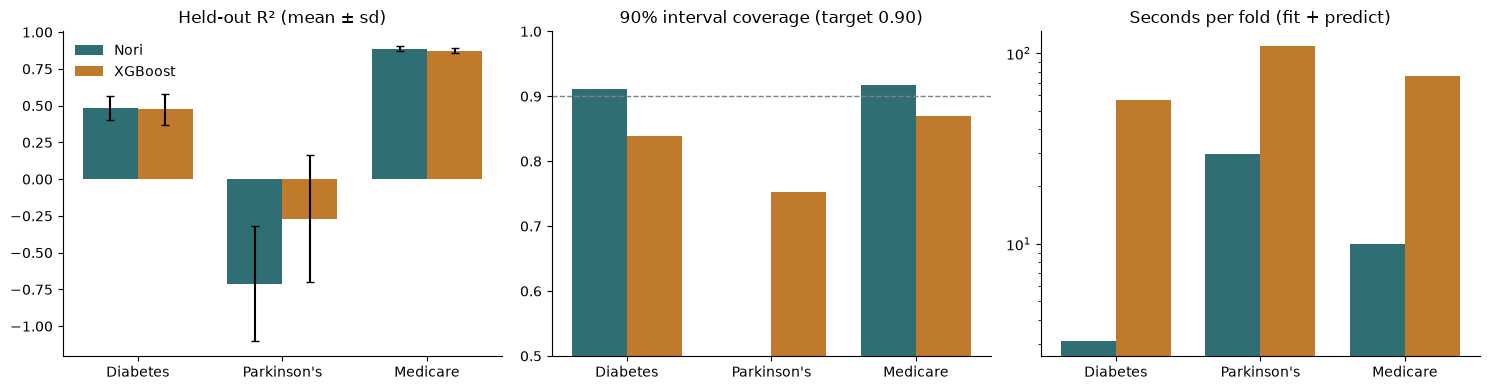

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"Nori": "#2f6f73", "XGBoost": "#c07a2c"}
names = list(DATASETS)
x = np.arange(len(names))
for i, model in enumerate(["Nori", "XGBoost"]):
    s = summary.xs(model, level="model").loc[names]
    axes[0].bar(x + (i - 0.5) * 0.38, s["R2"], 0.38, yerr=s["R2_sd"], label=model, color=colors[model], capsize=3)
    axes[1].bar(x + (i - 0.5) * 0.38, s["coverage"], 0.38, label=model, color=colors[model])
    axes[2].bar(x + (i - 0.5) * 0.38, s["seconds"], 0.38, label=model, color=colors[model])
axes[1].axhline(0.9, ls="--", c="grey", lw=1)
for ax, title in zip(axes, ["Held-out R² (mean ± sd)", "90% interval coverage (target 0.90)", "Seconds per fold (fit + predict)"]):
    ax.set_xticks(x, names)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].set_ylim(0.5, 1.0)
axes[2].set_yscale("log")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## How much data does each model need?

Clinical cohorts are often small: a single-site registry, a rare-disease panel, a new DRG. This curve holds a fixed 1,000-row Medicare test set and grows the training set from 50 rows, repeating each size three times with different draws.

In [8]:
SIZES = [50, 100, 250] if QUICK else [50, 100, 250, 500, 1000]
REPEATS = 1 if QUICK else 3
test_idx = np.random.default_rng(SEED).choice(len(y_mc), size=min(1000, len(y_mc) // 2), replace=False)
pool_idx = np.setdiff1d(np.arange(len(y_mc)), test_idx)
X_test_lc, y_test_lc = X_mc.iloc[test_idx], y_mc[test_idx]

curve = []
for size in SIZES:
    for rep in range(REPEATS):
        tr = np.random.default_rng(SEED + rep).choice(pool_idx, size=min(size, len(pool_idx)), replace=False)
        X_tr, y_tr = X_mc.iloc[tr], y_mc[tr]
        pred, *_ = run_nori(X_tr, y_tr, X_test_lc, MEDICARE_CATS)
        curve.append({"train rows": size, "rep": rep, "model": "Nori", "R2": r2_score(y_test_lc, pred)})
        pred, *_ = run_xgb(X_tr, y_tr, X_test_lc, None, n_iter=min(XGB_SEARCH_ITERS, 15))
        curve.append({"train rows": size, "rep": rep, "model": "XGBoost", "R2": r2_score(y_test_lc, pred)})
curve = pd.DataFrame(curve)
curve_summary = curve.pivot_table(index="train rows", columns="model", values="R2", aggfunc="mean").round(3)
curve_summary

model,Nori,XGBoost
train rows,,
50,-0.170,0.498
100,0.564,0.508
250,0.734,0.649
500,0.810,0.776
1000,0.863,0.834


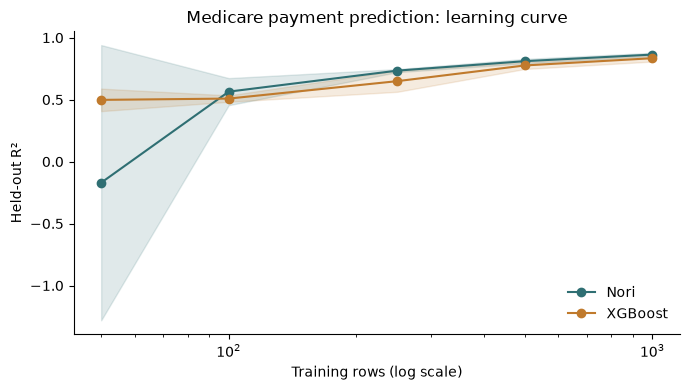

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for model, grp in curve.groupby("model"):
    agg = grp.groupby("train rows")["R2"].agg(["mean", "std"])
    ax.plot(agg.index, agg["mean"], marker="o", label=model, color=colors[model])
    ax.fill_between(agg.index, agg["mean"] - agg["std"], agg["mean"] + agg["std"], alpha=0.15, color=colors[model])
ax.set_xscale("log")
ax.set_xlabel("Training rows (log scale)")
ax.set_ylabel("Held-out R²")
ax.set_title("Medicare payment prediction: learning curve")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Leakage check: split by recording vs by patient

Each Parkinson's patient contributes about 140 voice recordings over six months. A random K-fold puts recordings from the same patient in both train and test, so a model can score well by recognizing the patient rather than learning how voice relates to symptom severity. The patient-grouped scores above are the honest ones; this cell shows how far a naive split would overstate them.

In [10]:
leaky = pd.DataFrame(evaluate("Parkinson's (random K-fold)", X_pk, y_pk, None, None,
                              KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)))
leak_table = pd.DataFrame({
    "patient-grouped R2": results[results.dataset == "Parkinson's"].groupby("model")["R2"].mean(),
    "random K-fold R2": leaky.groupby("model")["R2"].mean(),
})
leak_table["inflation"] = leak_table["random K-fold R2"] - leak_table["patient-grouped R2"]
leak_table.round(3)

Parkinson's (random K-fold) fold 0: Nori R2=0.992 | XGBoost R2=0.963


Parkinson's (random K-fold) fold 1: Nori R2=0.997 | XGBoost R2=0.971


Parkinson's (random K-fold) fold 2: Nori R2=0.994 | XGBoost R2=0.967


Parkinson's (random K-fold) fold 3: Nori R2=0.995 | XGBoost R2=0.970


Parkinson's (random K-fold) fold 4: Nori R2=0.994 | XGBoost R2=0.972


,patient-grouped R2,random K-fold R2,inflation
model,,,
Nori,-0.710,0.994,1.704
XGBoost,-0.268,0.969,1.236


## Findings

Figures are `nori-30m` on the GPU against the same tuned XGBoost, averaged over held-out folds.

**1. On Medicare payments, Nori wins every fold.** R² **0.888** vs **0.872**, 5 of 5 folds, with RMSE 6% lower (2,582 vs 2,761) and MAE 8% lower (1,367 vs 1,485). Nori took ~10 s per fold on the GPU; XGBoost's 30-configuration search took ~76 s on the CPU.

**2. On the small diabetes cohort, it is effectively a tie.** R² **0.484** vs **0.475**, Nori winning 6 of 10 folds, with no tuning at all (~3 s vs ~57 s per fold).

**3. Nori's intervals are better calibrated, and on Medicare also tighter.** 90% interval coverage is **0.91** (Diabetes) and **0.92** (Medicare) for Nori, against **0.84** and **0.87** for XGBoost's quantile model. On Medicare, Nori's intervals are also 20% narrower (6,049 vs 7,601). It gets them from the same forward pass.

**4. Neither model generalizes Parkinson's severity to new patients, and Nori fails harder.** With whole patients held out, both R² values are negative (Nori **−0.71**, XGBoost **−0.27**; XGBoost wins all 5 folds). Voice features in this dataset track *which patient* a recording came from better than *how severe* their disease is. Nori's 90% intervals cover only **22%** of held-out patients' scores, against **75%** for XGBoost. Its predictive distribution is confidently wrong under patient-level distribution shift, and the larger checkpoint does not fix that.

**5. Random splits hide that failure completely.** Splitting by recording instead of patient raises R² to **0.994** (Nori) and **0.969** (XGBoost), an inflation of +1.70 and +1.24. Nori benefits *more* from leakage because in-context learning can match a query to near-duplicate rows from the same patient. Any clinical benchmark of an in-context model needs a patient- or site-grouped split.

**6. From 100 rows up, Nori learns faster, but 50 rows is too few.** On the Medicare learning curve (mean of 3 draws per size), Nori leads at 100 (0.564 vs 0.508), 250 (0.734 vs 0.649), 500 (0.810 vs 0.776) and 1,000 rows (0.863 vs 0.834). At 50 rows its mean R² is **−0.17** against 0.50 for XGBoost.

### Does the bigger checkpoint matter?

Same folds, same XGBoost; only Nori's size and hardware change.

| Metric | `nori-6m` (CPU) | `nori-30m` (GPU) | XGBoost |
|---|---:|---:|---:|
| Diabetes R² | 0.488 | 0.484 | 0.475 |
| Medicare R² | 0.868 | **0.888** | 0.872 |
| Medicare folds won by Nori | 2 / 5 | **5 / 5** | – |
| Parkinson's (by patient) R² | −0.76 | −0.71 | **−0.27** |
| Parkinson's interval coverage | 0.20 | 0.22 | **0.75** |
| Learning curve R², 250 rows | 0.620 | **0.734** | 0.649 |
| Learning curve R², 50 rows | 0.14 | −0.17 | **0.50** |
| Nori seconds per Parkinson's fold | 376 | **30** | – |

The larger model turns Medicare from a tie into a clean win and lifts the 250–1,000-row curve by 0.05–0.11 R². On the small diabetes cohort it changes nothing, and it does not rescue new-patient generalization. On a GPU it is also about 13× faster than the small model on a CPU.

### When to reach for which

| Situation | Better default |
|---|---|
| A few hundred to a few thousand rows, a GPU available, calibrated intervals matter | **Nori** |
| Fewer than ~100 training rows | **XGBoost** |
| CPU-only scoring of thousands of rows, or strict latency | **XGBoost** |
| Deployment to new patients, sites, or payers (distribution shift) | **XGBoost**, and validate both with grouped CV |
| Any model | Split by patient/provider before trusting a score |

### Limitations

- Timings compare Nori on a laptop GPU with XGBoost on a laptop CPU; they show practical cost, not like-for-like hardware.
- `nori-100m` was not run: it does not fit comfortably in 6 GB.
- XGBoost search is 30 random configurations, not exhaustive; its quantile model reuses the point-model parameters.
- Medicare is a 4,000-row sample of 163k rows with a heavy-tailed target, split by row rather than by provider.
- Three datasets are a case study, not a benchmark suite.